In [23]:
import torch

# 1. 檢查 PyTorch 版本
print(f"PyTorch Version: {torch.__version__}")

# 2. 檢查 GPU 是否可用 (對應 tf.test.is_gpu_available())
is_gpu_available = torch.cuda.is_available()
print(f"GPU Available: {is_gpu_available}")

# 3. (額外建議) 如果有抓到 GPU，印出顯卡型號確認
if is_gpu_available:
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

PyTorch Version: 2.9.1+cu130
GPU Available: True
Device Name: NVIDIA GeForce RTX 3090


In [24]:
# import需要的模組

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from matplotlib import pyplot as plt
import time
import joblib

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import r2_score, mean_absolute_error


In [25]:
# 讀取data

train_df = pd.read_csv('effective_data.csv')
train_df.shape

(3033, 58)

In [26]:
x_train_image_data = train_df.values[:,0:25]
x_train_image_data = np.array(x_train_image_data)

In [27]:
x_train_data = train_df.values[:,25:46]
x_train_data = np.array(x_train_data)

In [28]:
y_train_data = train_df.values[:,-12:]
y_train_data = np.array(y_train_data)

目前資料筆數: 3033
預計擴增筆數: 467
擴增完成！最終資料筆數: 3500


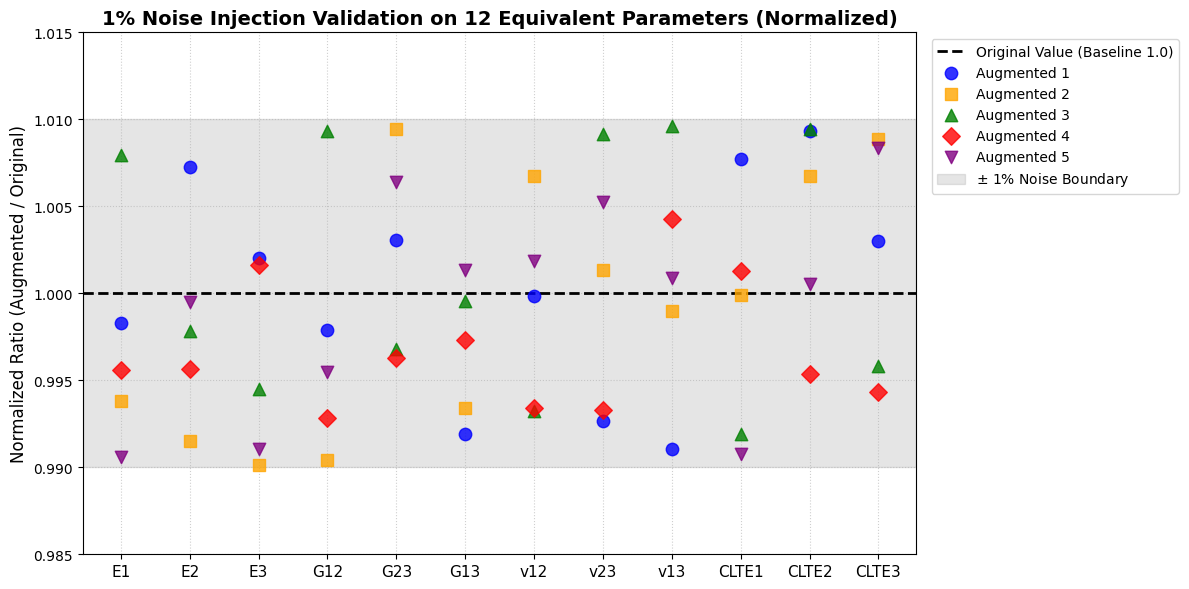

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 假設變數 x_train_data, x_train_image_data, y_train_data 目前長度為 3032

# 1. 設定擴增目標
target_size = 3500
current_size = len(x_train_data)
num_to_generate = target_size - current_size # 預計產生 468 筆

print(f"目前資料筆數: {current_size}")
print(f"預計擴增筆數: {num_to_generate}")

if num_to_generate > 0:
    # 2. 提取最新的 32 筆資料作為「基底 (Base)」
    # **修改：切片範圍改為 -32:**
    x_base = x_train_data[-33:]
    x_image_base = x_train_image_data[-33:]
    y_base = y_train_data[-33:]
    
    x_aug_list = []
    x_image_aug_list = []
    y_aug_list = []
    
    # 3. 隨機從這 32 筆中抽取來進行擴增
    base_indices = np.random.choice(len(x_base), size=num_to_generate, replace=True)
    
    for idx in base_indices:
        x_aug = np.copy(x_base[idx])
        x_image_aug = np.copy(x_image_base[idx])
        y_aug = np.copy(y_base[idx])
        
        # **新增：針對 12 個等效參數的噪音邏輯**
        # **與應力應變曲線的全域噪音不同，這 12 個參數代表不同的物理量，**
        # **因此我們生成一個長度為 12 的陣列，讓每個參數都有自己獨立的 +-1% 隨機變化**
        noise_ratios = np.random.uniform(-0.01, 0.01, size=len(y_aug))
        y_aug = y_aug * (1 + noise_ratios)
        
        x_aug_list.append(x_aug)
        x_image_aug_list.append(x_image_aug)
        y_aug_list.append(y_aug)
    
    # 4. 將擴增的資料與原始資料合併 (使用 concatenate 確保多維影像陣列安全拼接)
    x_train_data_expanded = np.concatenate((x_train_data, np.array(x_aug_list)), axis=0)
    x_train_image_data_expanded = np.concatenate((x_train_image_data, np.array(x_image_aug_list)), axis=0)
    y_train_data_expanded = np.concatenate((y_train_data, np.array(y_aug_list)), axis=0)
    
    print(f"擴增完成！最終資料筆數: {len(x_train_data_expanded)}")

    # 5. 繪圖比較 (使用「正規化比例」來克服數值級別差異過大的問題)
    plt.figure(figsize=(12, 6))

    # 取出基底的第 1 筆資料作為示範
    original_y = y_base[0]
    
    # 定義 X 軸的 12 個參數標籤
    properties = ['E1', 'E2', 'E3', 'G12', 'G23', 'G13', 
                  'v12', 'v23', 'v13', 'CLTE1', 'CLTE2', 'CLTE3']
    x_positions = np.arange(len(properties))

    # **繪製原始資料的基準線 (因為是自己除以自己，所以是一條位於 1.0 的黑色虛線)**
    plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='Original Value (Baseline 1.0)')

    # 從擴增資料中，找出從這筆「基底 0」衍生出來的前 5 筆進行對比
    plot_count = 0
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    markers = ['o', 's', '^', 'D', 'v']
    
    for i, base_idx in enumerate(base_indices):
        if base_idx == 0 and plot_count < 5:
            aug_y = y_aug_list[i]
            
            # **關鍵邏輯：將擴增後的數值除以原始數值，算出相對比例**
            normalized_aug_y = aug_y / original_y
            
            # 畫出這 12 個參數的相對變異點
            plt.scatter(x_positions, normalized_aug_y, 
                        label=f'Augmented {plot_count+1}', 
                        color=colors[plot_count], 
                        marker=markers[plot_count],
                        s=80, alpha=0.8, zorder=5)
            plot_count += 1

    # 畫出上下 1% 的容許邊界 (灰色背景區塊) 以供視覺參考
    plt.axhspan(0.99, 1.01, color='gray', alpha=0.2, label='$\pm$ 1% Noise Boundary')

    # 設定圖表標籤與格式
    plt.title('1% Noise Injection Validation on 12 Equivalent Parameters (Normalized)', fontsize=14, fontweight='bold')
    plt.xticks(x_positions, properties, fontsize=11)
    plt.ylabel('Normalized Ratio (Augmented / Original)', fontsize=12)
    
    # 限制 Y 軸的顯示範圍，讓 1% 的變化看起來更清晰
    plt.ylim(0.985, 1.015) 
    
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # 圖例設定在圖表外側避免遮擋資料點
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

else:
    print("目標筆數不大於目前筆數，不需擴增。")

In [30]:
# 讀取data前半部的編織物結構0101矩陣當作圖像輸入(woven structure)，並將圖像輸入分成train、test兩部分
x_train_image_data = x_train_image_data_expanded.reshape(x_train_image_data_expanded.shape[0],5,5,1)

x_train_image, x_test_image = train_test_split(x_train_image_data, test_size=0.15, random_state=8)

In [31]:
# 讀取data後半部的纖維、樹酯材料、幾何參數，並將性質輸入分成train、test
X_minMax = preprocessing.MinMaxScaler(feature_range=(0, 1)).fit(x_train_data_expanded)
x_train_data = X_minMax.transform(x_train_data_expanded)

x_train, x_test = train_test_split(x_train_data, test_size=0.15, random_state=8)
x_train_data.shape

(3500, 21)

In [32]:
joblib.dump(X_minMax, "effective_input_scaler.pkl")

['effective_input_scaler.pkl']

In [33]:
# 讀取data最後部分的模擬出來的編織物機械性質，並將機械性質輸出分成train、test
Y_minMax = preprocessing.MinMaxScaler(feature_range=(0, 1)).fit(y_train_data_expanded)
y_train_data = Y_minMax.transform(y_train_data_expanded)

y_train, y_test = train_test_split(y_train_data, test_size=0.15, random_state=8)

In [34]:
joblib.dump(Y_minMax, "effective_output_scaler.pkl")

['effective_output_scaler.pkl']

In [35]:
output_title = ['E1','E2','E3','G12','G23','G13','v12','v23','v13','CLTE1','CLTE2','CLTE3']

In [36]:
# 檢查分析label的分佈情況

y_train_data_np = np.array(train_df.values[:,-12:]).astype(float)
y_train_data_pd = pd.DataFrame(data=y_train_data_np,columns=output_title)

print(y_train_data_pd.describe())

                 E1            E2            E3           G12           G23  \
count  3.033000e+03  3.033000e+03  3.033000e+03  3.033000e+03  3.033000e+03   
mean   4.884349e+10  3.587448e+10  2.935706e+10  1.245851e+10  1.035457e+10   
std    1.357748e+10  9.488881e+09  6.962174e+09  3.058874e+09  2.850597e+09   
min    2.762200e+10  2.040000e+10  1.884700e+10  6.423300e+09  6.301300e+09   
25%    3.833100e+10  2.868100e+10  2.378200e+10  1.042000e+10  8.060500e+09   
50%    4.513500e+10  3.606000e+10  2.665300e+10  1.242300e+10  9.918100e+09   
75%    5.681400e+10  4.057700e+10  3.603000e+10  1.485500e+10  1.180000e+10   
max    9.185800e+10  6.868700e+10  4.628900e+10  2.050300e+10  1.833300e+10   

                G13          v12          v23          v13        CLTE1  \
count  3.033000e+03  3033.000000  3033.000000  3033.000000  3033.000000   
mean   1.062654e+10     0.281443     0.337324     0.316281     0.000028   
std    2.913825e+09     0.091637     0.093239     0.084095     

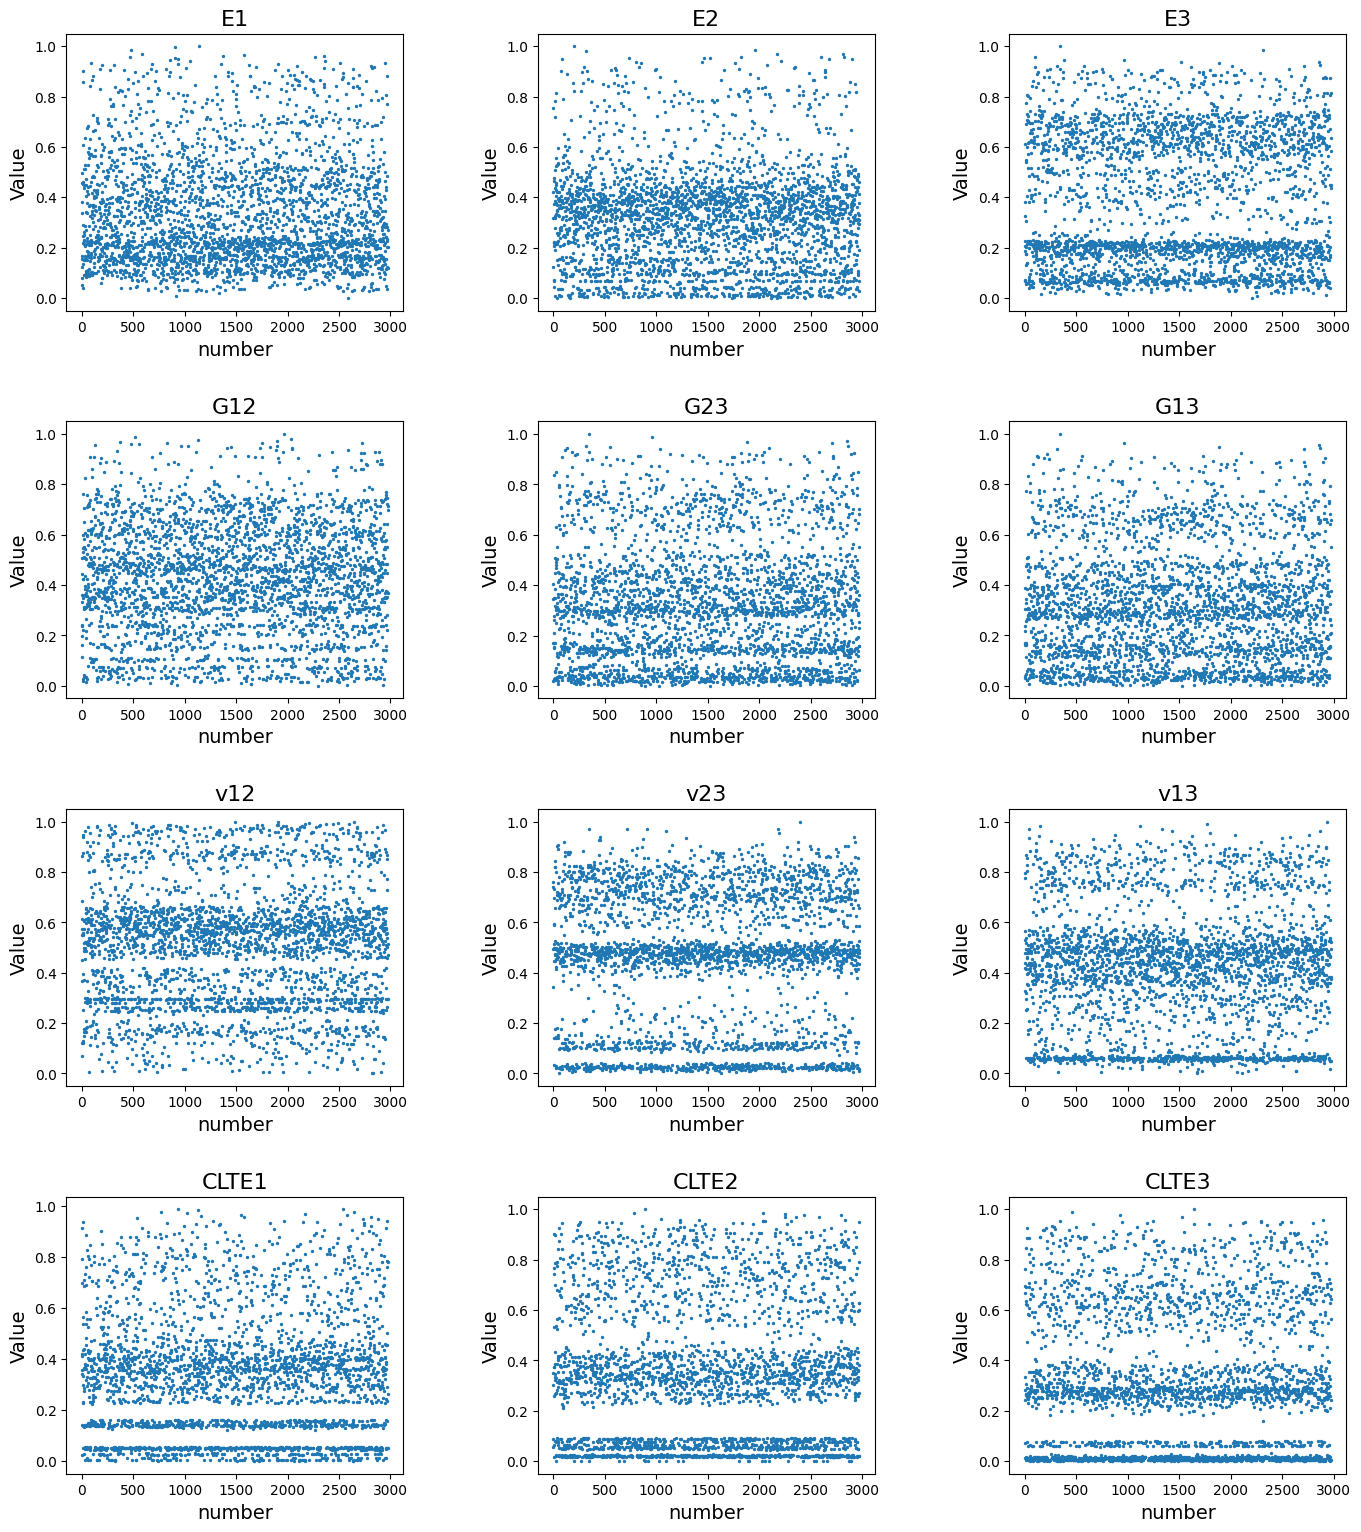

In [37]:
# 將label分佈圖像化

fig, ax = plt.subplots(4, 3)
i=0

for a in range(len(ax)): 
    for b in range(len(ax[a])):
        ax[a, b].scatter(np.arange(y_train[:,0].shape[0]),y_train[:,i],s=2)
        ax[a, b].set_title(output_title[i], fontsize=16)
        #ax[a, b].legend(['Train', 'Validation'], fontsize=12)
        ax[a, b].set_xlabel('number', fontsize=14)
        ax[a, b].set_ylabel('Value', fontsize=14)
        #ax[a, b].grid(linewidth=0.5)
        i=i+1

plt.subplots_adjust(left=0, bottom=0, right=2, top=3, wspace=0.4, hspace=0.4)
plt.show()

In [38]:
x_angle_data_new = train_df.values[3000:-3,25:26]
y_data_new = train_df.values[3000:-3,-12:]

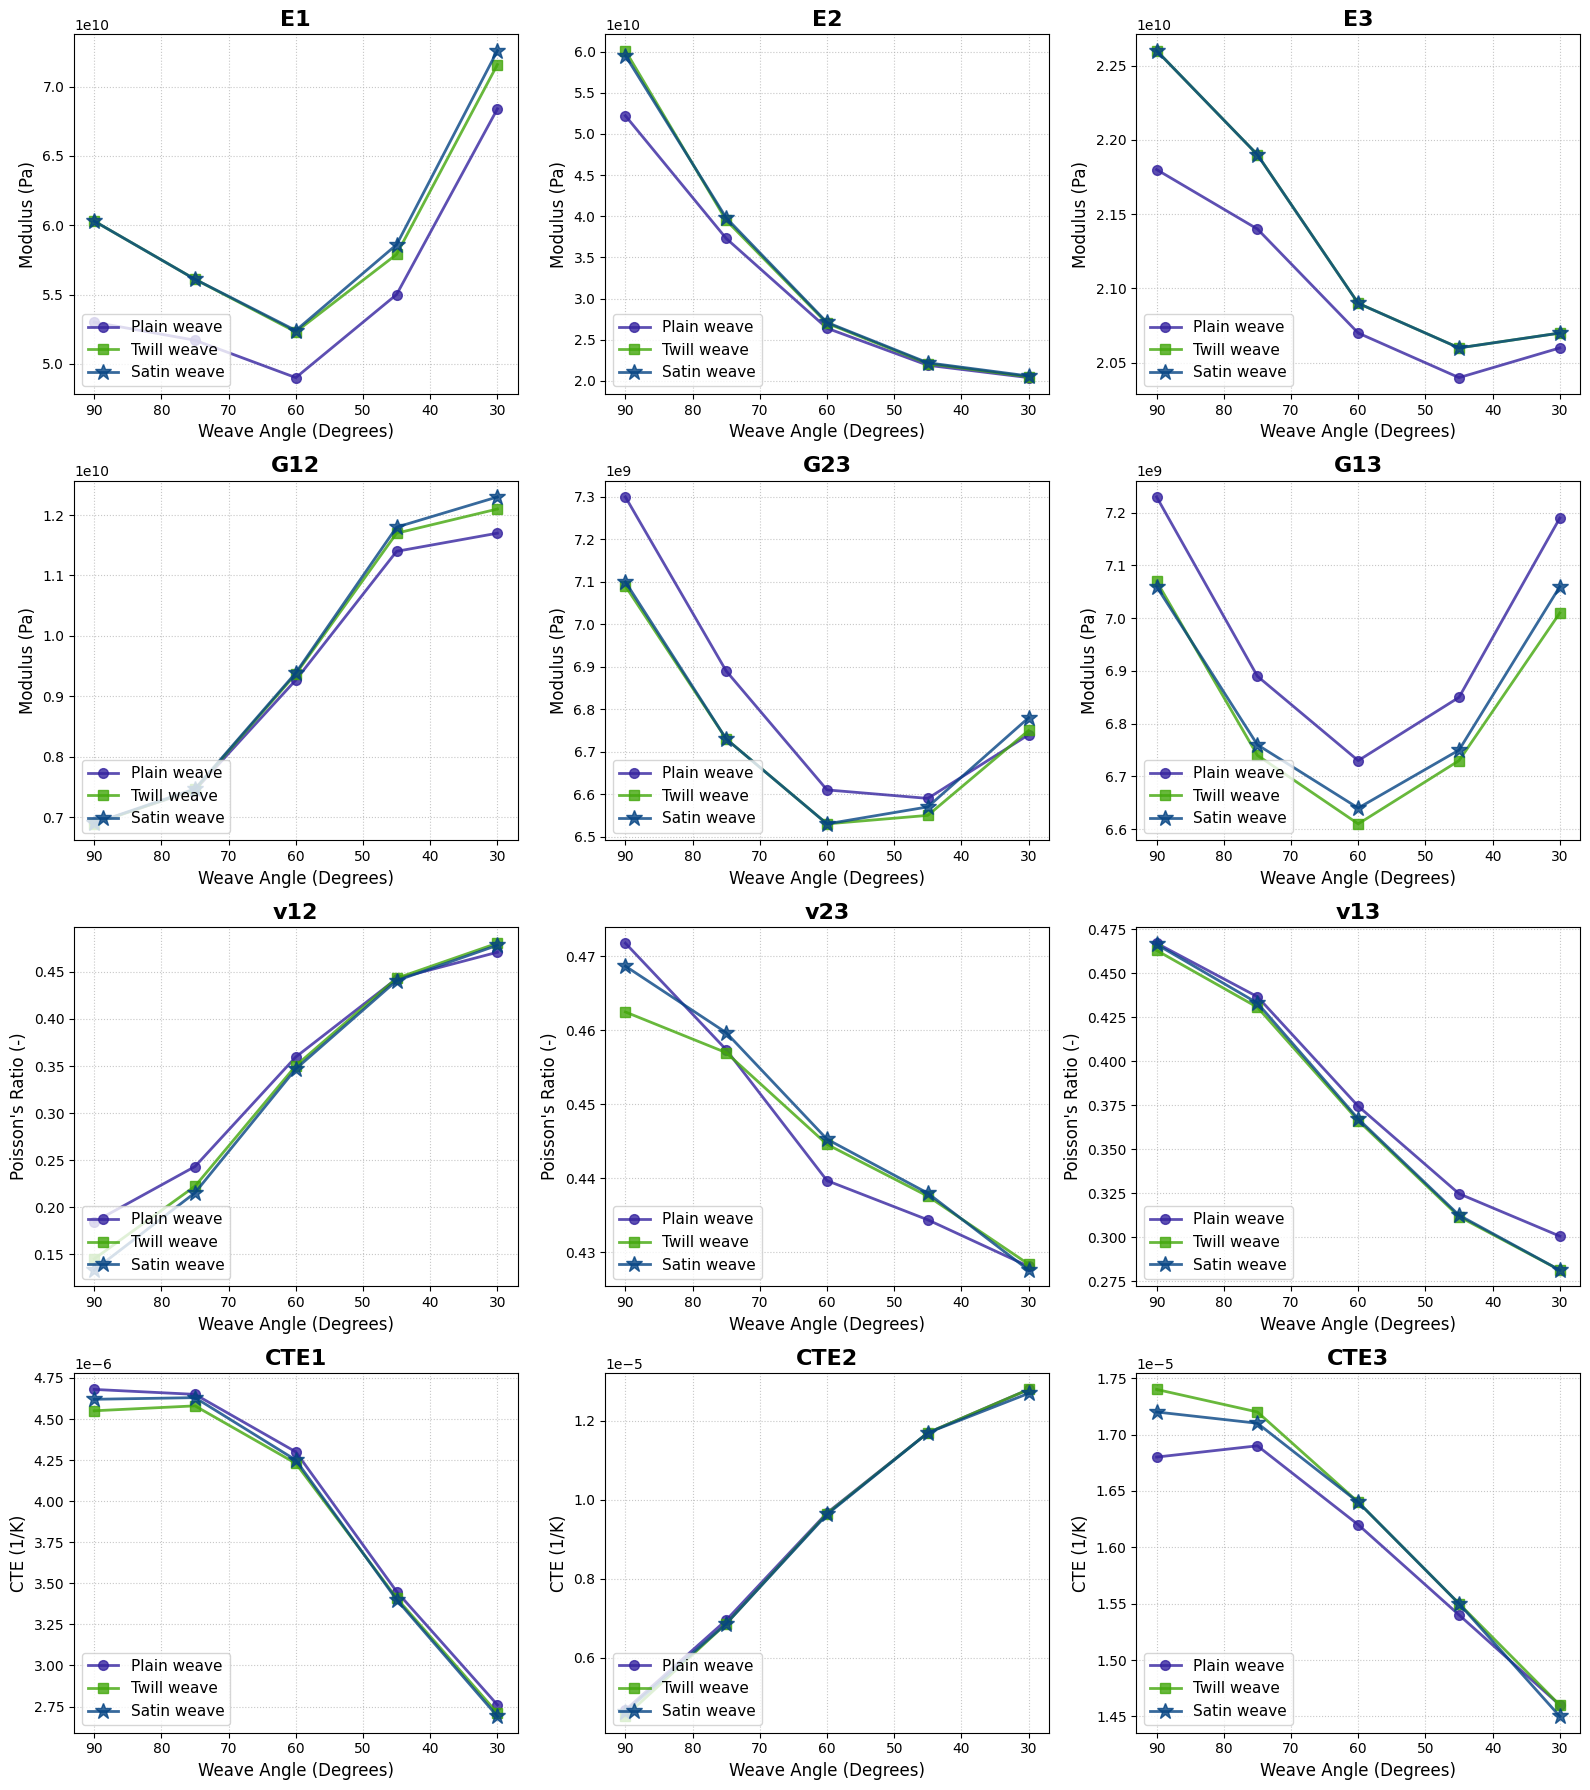

In [54]:
# 1. 取出前 15 筆資料 (針對第一組纖維與樹脂的組合)
x_subset = x_angle_data_new[-15:].flatten()
y_subset = y_data_new[-15:, :]
# x_subset = x_angle_data_new[:15].flatten()
# y_subset = y_data_new[:15, :]

# 2. 轉換角度
# 根據指示，將讀取到的 0, 15, 30, 45, 60 轉換為 90, 75, 60, 45, 30
# 轉換公式：實際角度 = 90 - 讀取角度
angles_converted = 90 - x_subset

# 3. 定義編織樣式的資料索引範圍 (每種樣式各 5 筆)
weave_styles = {
    'Plain weave': (0, 5),
    'Twill weave': (5, 10),
    'Satin weave': (10, 15)
}

# 定義 12 個等效參數的名稱，這將作為各個子圖的標題
properties = [
    'E1', 'E2', 'E3', 'G12', 'G23', 'G13', 
    'v12', 'v23', 'v13', 'CTE1', 'CTE2', 'CTE3'
]

# 4. 建立 4x3 的子圖矩陣，設定整體的畫布大小
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten() # 將 2D 陣列攤平，方便在迴圈中透過索引呼叫

# 定義不同編織樣式的顏色與標記符號，確保列印成黑白論文時也能具備辨識度
styles_format = {
    'Plain weave': {'color': "#35239F", 'marker': 'o', 'marker_size': 7},
    'Twill weave': {'color': "#42A70B", 'marker': 's', 'marker_size': 7},
    'Satin weave': {'color': "#054483" , 'marker': '*', 'marker_size': 12}
}

# 5. 使用迴圈針對每一個等效參數繪製趨勢圖
for i in range(12):
    ax = axes[i]
    
    # 在當前子圖中，畫出三種編織樣式的線條
    for style_name, (start, end) in weave_styles.items():
        # 取出該編織樣式對應的角度與等效參數值
        style_angles = angles_converted[start:end]
        style_values = y_subset[start:end, i]
        
        ax.plot(style_angles, style_values, 
                label=style_name, 
                color=styles_format[style_name]['color'], 
                marker=styles_format[style_name]['marker'], 
                linestyle='-', 
                linewidth=2,
                markersize=styles_format[style_name]['marker_size'], 
                alpha=0.8)
    
    # 設定圖表標籤與格式
    ax.set_title(f'{properties[i]}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Weave Angle (Degrees)', fontsize=12)
    
    # 針對應變、卜瓦松比與熱膨脹係數給予不同的 Y 軸標籤
    if properties[i].startswith('E') or properties[i].startswith('G'):
        ax.set_ylabel('Modulus (Pa)', fontsize=12)
    elif properties[i].startswith('v'):
        ax.set_ylabel('Poisson\'s Ratio (-)', fontsize=12)
    else:
        ax.set_ylabel('CTE (1/K)', fontsize=12)
    
    # 反轉 X 軸，讓角度由左至右呈現 90度 遞減至 30度 的視覺邏輯
    ax.invert_xaxis()
    
    # 開啟網格線
    ax.grid(True, linestyle=':', alpha=0.7)
    
    ax.legend(loc='lower left', fontsize=11)

# 自動調整子圖之間的間距，避免文字重疊
plt.tight_layout()

# 顯示圖表
plt.show()

In [40]:
class CompositeDualModel(nn.Module):
    def __init__(self):
        super().__init__()

        # --- 1. Image Branch (圖像路徑) ---
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=2, stride=2, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=2, stride=2, padding=1)
        self.dropout1 = nn.Dropout(0.2)
        self.conv3 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=2, stride=2, padding=0)
        self.conv4 = nn.Conv2d(in_channels=2, out_channels=2, kernel_size=2, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
        
        self.flatten = nn.Flatten()
        
        # [修正點 1] 這裡原本是 2*2*2=8，但根據錯誤訊息，PyTorch 實際算出來是 18
        # 所以我們直接改成 18 讓它通過
        self.img_dense_block = nn.Sequential(
            nn.Linear(18, 960), 
            nn.ReLU(),
            nn.Linear(960, 480),
            nn.ReLU(),
            nn.Linear(480, 240),
            nn.ReLU(),
            nn.Linear(240, 120),
            nn.ReLU()
        )

        # --- 2. Info Branch (性質路徑) ---
        self.info_dense_block = nn.Sequential(
            nn.Linear(21, 64),
            nn.ReLU(),
            nn.Linear(64, 48),
            nn.ReLU(),
            nn.Linear(48, 36),
            nn.ReLU(),
            nn.Linear(36, 24),
            nn.ReLU()
        )

        # --- 3. Combined Path (結合後路徑) ---
        self.c_conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=2, stride=1, padding=0)
        self.c_conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=2, stride=1, padding=1)
        self.c_conv3 = nn.Conv2d(in_channels=16, out_channels=12, kernel_size=2, stride=1, padding=1)
        
        # [修正點 2] 預防下一個錯誤
        # 經過計算，PyTorch 的 padding=1 會讓尺寸稍微變大：
        # Input 12x12 -> c_conv1(valid) -> 11x11
        # 11x11 -> c_conv2(pad=1) -> 12x12
        # 12x12 -> c_conv3(pad=1) -> 13x13
        # 所以最終 Flatten 大小是：12 (channels) * 13 * 13 = 2028
        self.final_dense_block = nn.Sequential(
            nn.Linear(12 * 13 * 13, 1920), 
            nn.ReLU(),
            nn.Linear(1920, 960),
            nn.ReLU(),
            nn.Linear(960, 480),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(480, 240),
            nn.ReLU(),
            nn.Linear(240, 120),
            nn.ReLU(),
            nn.Linear(120, 12)
        )

    def forward(self, img_input, info_input):
        # 轉置圖片維度 (Batch, 5, 5, 1) -> (Batch, 1, 5, 5)
        if img_input.shape[-1] == 1: 
            x1 = img_input.permute(0, 3, 1, 2)
        else:
            x1 = img_input
            
        x1 = self.relu(self.conv1(x1))
        x1 = self.relu(self.conv2(x1))
        x1 = self.dropout1(x1)
        x1 = self.relu(self.conv3(x1))
        x1 = self.relu(self.conv4(x1))
        x1 = self.pool1(x1)
        x1 = self.flatten(x1)
        
        # Debug: 如果未來改參數又報錯，請取消下面這行註解看實際形狀
        # print(f"x1 shape: {x1.shape}")
        
        x1 = self.img_dense_block(x1)

        x2 = self.info_dense_block(info_input)

        combined = torch.cat((x1, x2), dim=1)
        
        # Reshape: 144 -> 12x12 image
        combined = combined.view(-1, 1, 12, 12)

        c = self.relu(self.c_conv1(combined))
        c = self.relu(self.c_conv2(c))
        c = self.relu(self.c_conv3(c))
        c = self.flatten(c)
        
        # Debug: 如果未來改參數又報錯，請取消下面這行註解看實際形狀
        # print(f"c shape: {c.shape}")
        
        output = self.final_dense_block(c)
        
        return output

In [41]:
# --- 初始化模型 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CompositeDualModel().to(device)

# --- 定義 Optimizer 與 Loss (對應 model.compile) ---
# Keras: Adam(lr=0.001, decay=0.001)
# PyTorch 的 decay 通常是指 weight_decay (L2 regularization)
# 如果 Keras 的 decay 是指 learning rate decay，用法會不同，這邊先設 weight_decay=0.001
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
criterion = nn.MSELoss()

print(model)

CompositeDualModel(
  (conv1): Conv2d(1, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (relu): ReLU()
  (conv2): Conv2d(3, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(3, 2, kernel_size=(2, 2), stride=(2, 2))
  (conv4): Conv2d(2, 2, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=1, padding=1, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (img_dense_block): Sequential(
    (0): Linear(in_features=18, out_features=960, bias=True)
    (1): ReLU()
    (2): Linear(in_features=960, out_features=480, bias=True)
    (3): ReLU()
    (4): Linear(in_features=480, out_features=240, bias=True)
    (5): ReLU()
    (6): Linear(in_features=240, out_features=120, bias=True)
    (7): ReLU()
  )
  (info_dense_block): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=

In [42]:
from torch.utils.data import DataLoader, Dataset, random_split

# 假設 x_train_image, x_train, y_train 已經在您的記憶體中
# 且已經做完標準化 (Scaler)

# --- 定義雙輸入資料集 ---
class DualInputDataset(Dataset):
    def __init__(self, images, infos, targets):
        # 轉為 PyTorch Tensor，並確保是 Float 型態
        self.images = torch.tensor(images, dtype=torch.float32)
        self.infos = torch.tensor(infos, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.images[idx], self.infos[idx], self.targets[idx]

# --- 手動切分驗證集 (對應 validation_split=0.15) ---
# Keras 的 validation_split 是取後 15%，這裡我們用 train_test_split 隨機切分 (通常更好)
# 如果要完全模仿 Keras 的行為 (切最後 15%)，可以用陣列切片
X_img_train_split, X_img_val_split, X_info_train_split, X_info_val_split, y_train_split, y_val_split = train_test_split(
    x_train_image, x_train, y_train, 
    test_size=0.15, 
    random_state=42
)

# 建立 Dataset
train_dataset = DualInputDataset(X_img_train_split, X_info_train_split, y_train_split)
val_dataset = DualInputDataset(X_img_val_split, X_info_val_split, y_val_split)

# 建立 DataLoader (對應 batch_size=256)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print(f"訓練集數量: {len(train_dataset)}, 驗證集數量: {len(val_dataset)}")

訓練集數量: 2528, 驗證集數量: 447


In [43]:
import copy

class EarlyStopper:
    def __init__(self, patience=200, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')
        self.best_model_state = None

    def early_stop(self, validation_loss, model):
        # 如果 Loss 創新低
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
            # 暫存最佳權重 (對應 restore_best_weights=True)
            self.best_model_state = copy.deepcopy(model.state_dict())
            # 存檔 (對應 ModelCheckpoint save_best_only=True)
            torch.save(model.state_dict(), 'effective_model_ckp_pytorch.pth')
            print(f"  [Checkpoint] Validation Loss Improved. Model Saved.")
            return False
        # 如果 Loss 沒有顯著下降
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False
    
    def load_best_weights(self, model):
        if self.best_model_state:
            model.load_state_dict(self.best_model_state)
            print("  [Restoring] Restored best model weights.")

In [ ]:
# 設定訓練參數
epochs = 3000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 初始化模型、優化器、損失函數
# 注意：這裡使用我們上一段定義的 CompositeDualModel
model = CompositeDualModel().to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1e-7) # Keras 預設參數
criterion = nn.MSELoss() # 對應 loss='mse'

# 初始化早停物件
early_stopper = EarlyStopper(patience=100)

# 開始計時
start = time.time()
print("Training started...")

history = {'loss': [], 'val_loss': []} # 用來存 Loss 畫圖用

for epoch in range(epochs):
    # --- 訓練階段 (Training) ---
    model.train()
    running_loss = 0.0
    for img_batch, info_batch, target_batch in train_loader:
        # 搬移數據到 GPU
        img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
        
        # 1. 歸零梯度
        optimizer.zero_grad()
        # 2. 前向傳播
        outputs = model(img_batch, info_batch)
        # 3. 計算 Loss
        loss = criterion(outputs, target_batch)
        # 4. 反向傳播
        loss.backward()
        # 5. 更新權重
        optimizer.step()
        
        running_loss += loss.item() * img_batch.size(0) # 累加 Loss
    
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # --- 驗證階段 (Validation) ---
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad(): # 驗證時不需要計算梯度，節省記憶體
        for img_batch, info_batch, target_batch in val_loader:
            img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
            outputs = model(img_batch, info_batch)
            loss = criterion(outputs, target_batch)
            val_running_loss += loss.item() * img_batch.size(0)
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    
    # --- 紀錄與印出 ---
    history['loss'].append(epoch_loss)
    history['val_loss'].append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.6f} - val_loss: {epoch_val_loss:.6f}")
    
    # --- 檢查早停與存檔 ---
    if early_stopper.early_stop(epoch_val_loss, model):
        print("Early stopping triggered!")
        break

# 恢復最佳權重
early_stopper.load_best_weights(model)

# 最終存檔
torch.save(model.state_dict(), 'effective_model_pytorch.pth')

end = time.time()
print('Training has finished')
print('spend time is : ', end-start)

Using device: cuda
Training started...
Epoch 1/3000 - loss: 0.114823 - val_loss: 0.071387
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 2/3000 - loss: 0.062205 - val_loss: 0.062927
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 3/3000 - loss: 0.058470 - val_loss: 0.062283
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 4/3000 - loss: 0.057952 - val_loss: 0.061666
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 5/3000 - loss: 0.057729 - val_loss: 0.062288
Epoch 6/3000 - loss: 0.057999 - val_loss: 0.061944
Epoch 7/3000 - loss: 0.057316 - val_loss: 0.060662
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 8/3000 - loss: 0.056049 - val_loss: 0.057985
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 9/3000 - loss: 0.053421 - val_loss: 0.056896
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 10/3000 - loss: 0.052341 - val_loss: 0.055383
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 11/3000 - lo

In [22]:
import torch

# 1. 載入原始的 27MB 模型
model = CompositeDualModel()
model.load_state_dict(torch.load("effective_model_pytorch.pth"))

# 2. 轉換為半精度 (FP16)
model.half()

# 3. 儲存瘦身後的新模型
torch.save(model.state_dict(), "effective_model_pytorch_half.pth")

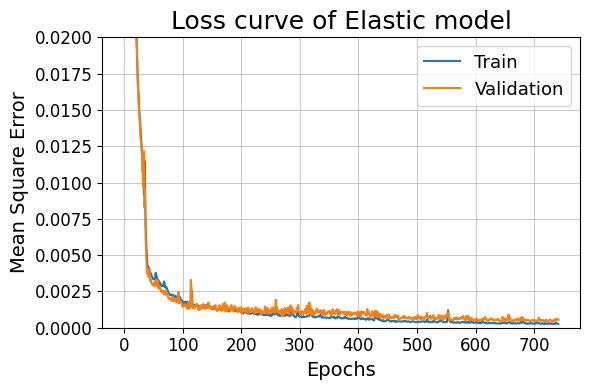

In [ ]:
# 將訓練過程圖像化 - Loss

plt.figure(figsize=(6,4))
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('Loss curve of Elastic model', fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0,0.02)
plt.grid(linewidth=0.5)
plt.legend(['Train', 'Validation'], fontsize=13)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Mean Square Error', fontsize=14)
# plt.ylabel('Loss', fontsize=14)
plt.tight_layout()
plt.savefig('Loss.png', dpi=400)
plt.show()

In [44]:
import torch

# 1. 先把模型架構「叫」出來 (必須使用我們剛剛修正過維度錯誤的那個 Class)
# 確保您的程式碼中有定義 CompositeDualModel 類別
model = CompositeDualModel() 

# 2. 載入權重檔案
# map_location='cpu' 是為了防止您在 GPU 訓練但在 CPU 電腦上跑預測時出錯
checkpoint_path = 'effective_model_pytorch.pth'
try:
    model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))
    print(f"✅ 成功載入模型: {checkpoint_path}")
except FileNotFoundError:
    print(f"❌ 找不到檔案: {checkpoint_path} (請確認剛剛訓練有沒有成功存檔)")

# 3. 切換到「評估模式」 (非常重要！)
# 這會凍結 Dropout 和 BatchNorm，否則預測結果會不穩定
model = model.to(device)
model.eval()

✅ 成功載入模型: effective_model_pytorch.pth


CompositeDualModel(
  (conv1): Conv2d(1, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (relu): ReLU()
  (conv2): Conv2d(3, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(3, 2, kernel_size=(2, 2), stride=(2, 2))
  (conv4): Conv2d(2, 2, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=1, padding=1, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (img_dense_block): Sequential(
    (0): Linear(in_features=18, out_features=960, bias=True)
    (1): ReLU()
    (2): Linear(in_features=960, out_features=480, bias=True)
    (3): ReLU()
    (4): Linear(in_features=480, out_features=240, bias=True)
    (5): ReLU()
    (6): Linear(in_features=240, out_features=120, bias=True)
    (7): ReLU()
  )
  (info_dense_block): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=

In [45]:
# ==========================================
# 進行預測與指標計算
# ==========================================
all_predictions = []
all_ground_truth = []

print("開始進行雙階段模型(CompositeDualModel)評估與指標計算...")

with torch.no_grad(): 
    # 使用與訓練時相同的 val_loader
    for img_batch, info_batch, target_batch in val_loader:
        img_batch, info_batch = img_batch.to(device), info_batch.to(device)
        
        # 雙階段模型的前向傳播
        outputs = model(img_batch, info_batch)
        
        # 收集預測結果與真實值
        all_predictions.append(outputs.cpu().numpy())
        all_ground_truth.append(target_batch.cpu().numpy())

# 將收集到的批次數據還原為完整的 NumPy 矩陣
all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

# ==========================================
# 進行反正規化還原 (Inverse Transform)
# ==========================================
# 將預測值與真實標籤還原回真實物理尺度
all_ground_truth_inv = Y_minMax.inverse_transform(all_ground_truth)
all_predictions_inv = Y_minMax.inverse_transform(all_predictions)

# ==========================================
# 核心指標計算 (基於還原後的 12 個彈性常數)
# ==========================================

# 1. 計算 決定係數 (R2 Score)
mlp_r2 = r2_score(all_ground_truth_inv, all_predictions_inv)

# 2. 計算 平均絕對誤差 (MAE)
mlp_mae = mean_absolute_error(all_ground_truth_inv, all_predictions_inv)

# 3. 計算 平均相對誤差 (MRE)
# 加上 1e-8 的 epsilon 是為了防止分母可能為零的除錯機制，確保計算數值穩定
epsilon = 1e-8
mlp_mre = np.mean(np.abs((all_ground_truth_inv - all_predictions_inv) / (all_ground_truth_inv + epsilon))) * 100

# ==========================================
# 印出評估結果
# ==========================================
print("\n" + "="*40)
print("[Flattened MLP 線彈性模型評估結果 (已反正規化)]")
print(f"整體 R2 Score: {mlp_r2:.4f}")
print(f"整體 MAE: {mlp_mae:.4f}") 
print(f"整體 平均相對誤差 (MRE): {mlp_mre:.2f}%")
print("="*40)

開始進行雙階段模型(CompositeDualModel)評估與指標計算...

[Flattened MLP 線彈性模型評估結果 (已反正規化)]
整體 R2 Score: 0.9928
整體 MAE: 222658240.0000
整體 平均相對誤差 (MRE): 2.31%


In [46]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"正在使用裝置: {device}")

model.to(device)
# 1. 確保模型在評估模式 (這會關閉 Dropout)
model.eval()

# 2. 準備數據：將 Numpy 轉為 Tensor 並搬移到 GPU
# 假設 x_train_image 等變數目前是 Numpy Arrays

# --- 處理訓練集 (Train) ---
# 注意 dtype=torch.float32 是必須的
x_train_img_tensor = torch.tensor(x_train_image, dtype=torch.float32).to(device)
x_train_info_tensor = torch.tensor(x_train, dtype=torch.float32).to(device)

# --- 處理測試集 (Test) ---
x_test_img_tensor = torch.tensor(x_test_image, dtype=torch.float32).to(device)
x_test_info_tensor = torch.tensor(x_test, dtype=torch.float32).to(device)

# 3. 執行預測 (Inference)
with torch.no_grad(): # 告訴 PyTorch 不要計算梯度，節省記憶體並加速
    # 預測訓練集
    train_output = model(x_train_img_tensor, x_train_info_tensor)
    # 將 Tensor 搬回 CPU 並轉成 Numpy
    y_pred = train_output.cpu().numpy()

    # 預測測試集
    test_output = model(x_test_img_tensor, x_test_info_tensor)
    y_pred_test = test_output.cpu().numpy()

# 4. 形狀確認 (Optional)
# PyTorch 出來的形狀通常已經是 (N, 12)，不需要像 Keras 有時候要硬 reshape
# 但為了保險起見，保留您的 reshape 邏輯也沒問題
# y_pred = y_pred.reshape(2550, 12)
# y_pred_test = y_pred_test.reshape(450, 12)

print(f"y_pred shape: {y_pred.shape}")         # 預期 (2550, 12)
print(f"y_pred_test shape: {y_pred_test.shape}") # 預期 (450, 12)

# 5. 反標準化 (Inverse Transform)
# 這部分跟原本一模一樣，因為 Y_minMax 是 Scikit-Learn 的物件，吃的是 Numpy
y_pred_inverse = Y_minMax.inverse_transform(y_pred)
y_train_inverse = Y_minMax.inverse_transform(y_train)

y_pred_test_inverse = Y_minMax.inverse_transform(y_pred_test)
y_test_inverse = Y_minMax.inverse_transform(y_test)

# 檢查一下結果
print("✅ 預測與反標準化完成")
print(f"Sample Prediction (Inverse): {y_pred_inverse[0]}")

正在使用裝置: cuda
y_pred shape: (2975, 12)
y_pred_test shape: (525, 12)
✅ 預測與反標準化完成
Sample Prediction (Inverse): [5.4130893e+10 4.0278356e+10 2.4655147e+10 8.8861041e+09 8.1577646e+09
 8.2109184e+09 2.3909023e-01 4.4501960e-01 4.3114236e-01 2.7506727e-05
 3.3552042e-05 5.5767625e-05]


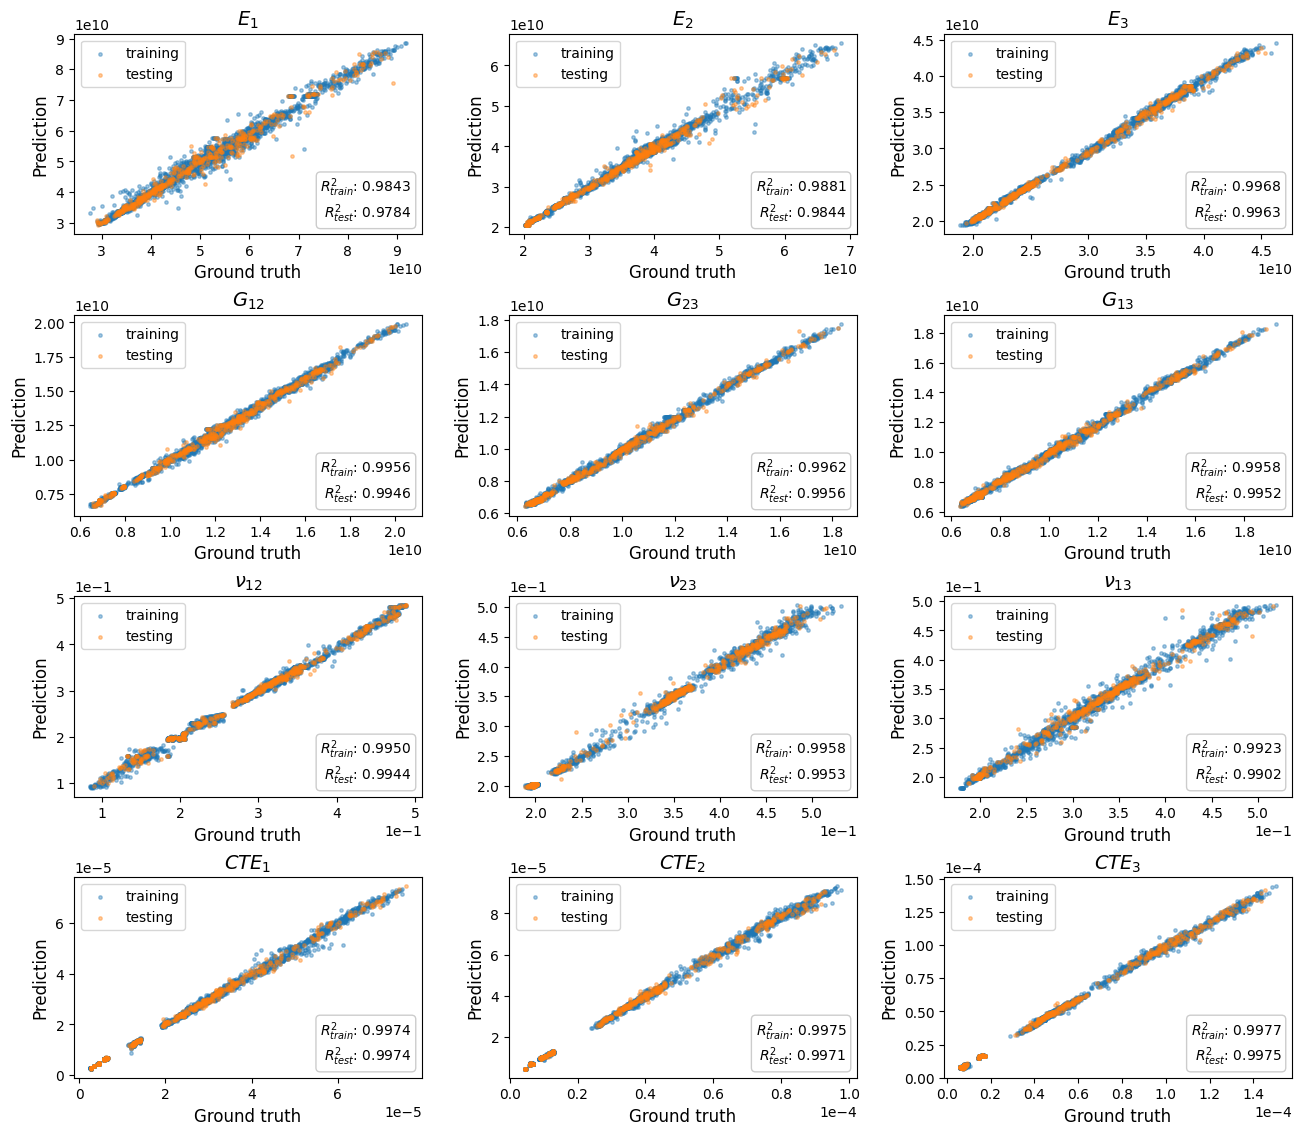

In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import r2_score  # 新增：匯入 R2 分數計算模組

# 1. 建立具有下標的標題清單 (使用 LaTeX 語法)
formatted_titles = [
    r'$E_1$', r'$E_2$', r'$E_3$',
    r'$G_{12}$', r'$G_{23}$', r'$G_{13}$',
    r'$\nu_{12}$', r'$\nu_{23}$', r'$\nu_{13}$',
    r'$CTE_1$', r'$CTE_2$', r'$CTE_3$'
]

fig, ax = plt.subplots(4, 3, figsize=(14, 12))
i = 0

for a in range(len(ax)): 
    for b in range(len(ax[a])):
        # 繪製散佈圖
        ax[a, b].scatter(y_train_inverse[:, i], y_pred_inverse[:, i], s=6, alpha=0.4)
        ax[a, b].scatter(y_test_inverse[:, i], y_pred_test_inverse[:, i], s=6, alpha=0.4)
        
        # 設定標題與軸標籤
        ax[a, b].set_title(formatted_titles[i], fontsize=14)
        ax[a, b].set_xlabel('Ground truth', fontsize=12)
        ax[a, b].set_ylabel('Prediction', fontsize=12)
        
        # 強制使用科學記號
        ax[a, b].ticklabel_format(style='sci', scilimits=(0, 0), axis='both')
        ax[a, b].legend(['training', 'testing'], loc='upper left', fontsize=10)
        
        # ==========================================================
        # 新增：計算 R2 分數並在右下角加上文字方塊
        # ==========================================================
        r2_train = r2_score(y_train_inverse[:, i], y_pred_inverse[:, i])
        r2_test = r2_score(y_test_inverse[:, i], y_pred_test_inverse[:, i])
        
        # 設定要顯示的文字內容 (包含 LaTeX 格式的 R^2)
        text_str = f'$R^2_{{train}}$: {r2_train:.4f}\n$R^2_{{test}}$: {r2_test:.4f}'
        
        # 使用 transform=ax[a, b].transAxes 讓座標 (0.95, 0.05) 對齊右下角
        # bbox 參數加入白底與些微透明度，避免文字與資料點重疊導致難以辨識
        ax[a, b].text(0.97, 0.05, text_str, transform=ax[a, b].transAxes, 
                      fontsize=10, verticalalignment='bottom', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))
        # ==========================================================
        
        i = i + 1

# 控制圖表間距
plt.subplots_adjust(left=0.08, right=0.95, bottom=0.08, top=0.95, wspace=0.25, hspace=0.4)
plt.savefig("effective_modulus_results.png", dpi=400)

plt.show()

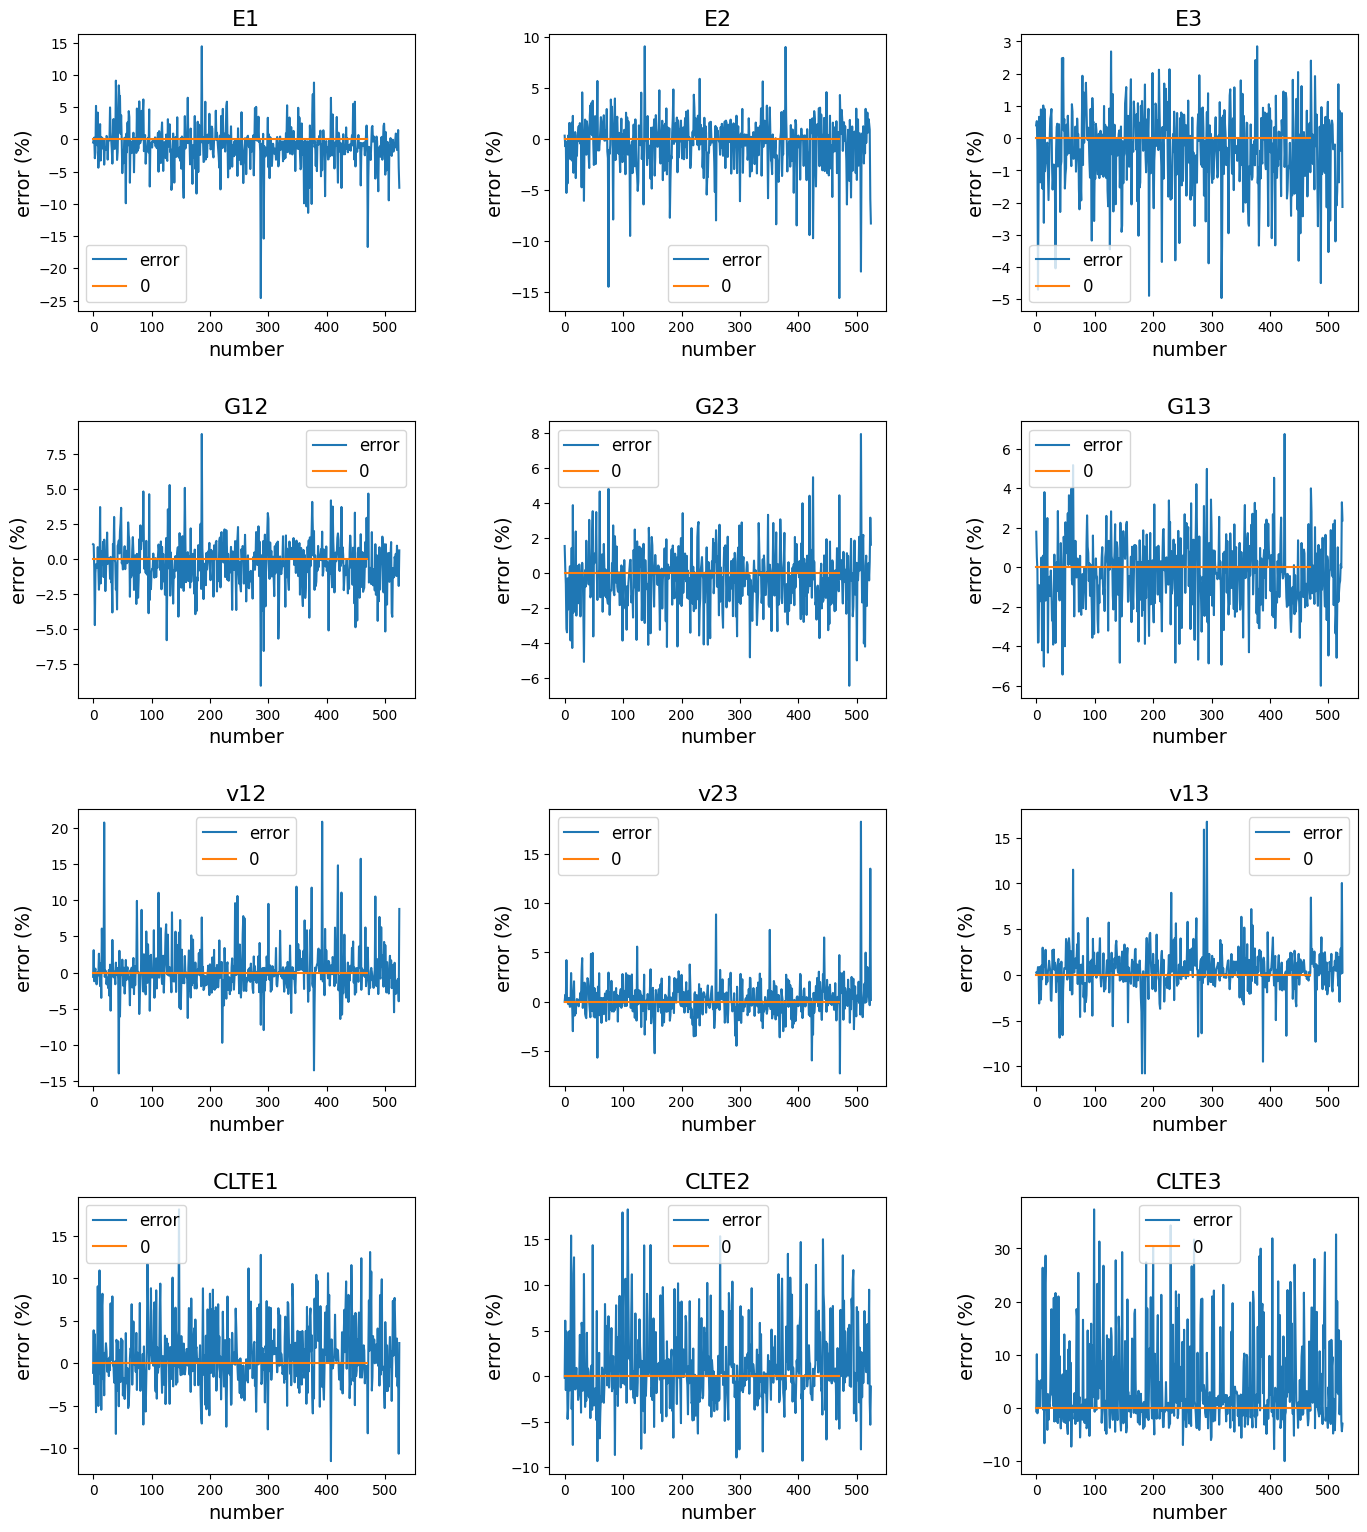

In [ ]:
# 將每項output的誤差百分比圖像化(test)

fig, ax = plt.subplots(4, 3)
i=0

for a in range(len(ax)): 
    for b in range(len(ax[a])):
        error = ((y_pred_test_inverse.T[i] - y_test_inverse.T[i])/y_test_inverse.T[i])*100
        ax[a, b].plot(error)
        ax[a, b].plot(np.linspace(0,0,470))
        ax[a, b].set_title(output_title[i], fontsize=16)
        ax[a, b].set_xlabel('number', fontsize=14)
        ax[a, b].set_ylabel('error (%)', fontsize=14)
        ax[a, b].legend(['error', '0'], fontsize=12)
        i=i+1

plt.subplots_adjust(left=0, bottom=0, right=2, top=3, wspace=0.4, hspace=0.4)
plt.show()

In [ ]:
# test:找出每項output最大、最小、平均的誤差以及發生最大誤差時的數值比較

for i in range(0,12):
    error = abs(y_pred_test_inverse.T[i] - y_test_inverse.T[i])/y_test_inverse.T[i]
    avg_error = sum(abs(y_pred_test_inverse.T[i] - y_test_inverse.T[i])/y_test_inverse.T[i])/y_pred_test.shape[0]
    print(str(output_title[i]), 'error avg : {:.3%}'.format(avg_error))
    print(str(output_title[i]), 'error min : {:.5%}'.format(min(error)))
    print(str(output_title[i]), 'error max : {:.3%}'.format(max(error)))
    
    error = error.tolist()
    print('The index of maximum error : %d' % error.index(max(error)))
    print(str(output_title[i]), 'pred', error.index(max(error)), ': %3.3e' % y_pred_test_inverse.T[i, error.index(max(error))])
    print(str(output_title[i]), 'test', error.index(max(error)), ': %3.3e' % y_test_inverse.T[i, error.index(max(error))])
    print('----------')

E1 error avg : 2.273%
E1 error min : 0.00187%
E1 error max : 24.619%
The index of maximum error : 287
E1 pred 287 : 5.177e+10
E1 test 287 : 6.868e+10
----------
E2 error avg : 1.836%
E2 error min : 0.01406%
E2 error max : 15.606%
The index of maximum error : 470
E2 pred 470 : 4.091e+10
E2 test 470 : 4.847e+10
----------
E3 error avg : 0.982%
E3 error min : 0.00328%
E3 error max : 4.960%
The index of maximum error : 317
E3 pred 317 : 3.536e+10
E3 test 317 : 3.721e+10
----------
G12 error avg : 1.288%
G12 error min : 0.00184%
G12 error max : 9.060%
The index of maximum error : 287
G12 pred 287 : 1.110e+10
G12 test 287 : 1.220e+10
----------
G23 error avg : 1.293%
G23 error min : 0.00476%
G23 error max : 7.929%
The index of maximum error : 507
G23 pred 507 : 1.142e+10
G23 test 507 : 1.058e+10
----------
G13 error avg : 1.439%
G13 error min : 0.00051%
G13 error max : 6.752%
The index of maximum error : 425
G13 pred 425 : 7.791e+09
G13 test 425 : 7.298e+09
----------
v12 error avg : 2.102%


In [ ]:
# train:找出每項output最大、最小、平均的誤差以及發生最大誤差時的數值比較

for i in range(0,12):
    error = abs(y_pred_inverse.T[i] - y_train_inverse.T[i])/y_train_inverse.T[i]
    avg_error = sum(abs(y_pred_inverse.T[i] - y_train_inverse.T[i])/y_train_inverse.T[i])/y_pred.shape[0]
    print(str(output_title[i]), 'error avg : {:.3%}'.format(avg_error))
    print(str(output_title[i]), 'error min : {:.5%}'.format(min(error)))
    print(str(output_title[i]), 'error max : {:.3%}'.format(max(error)))
    
    error = error.tolist()
    print('The index of maximum error : %d' % error.index(max(error)))
    print(str(output_title[i]), 'pred', error.index(max(error)), ': %3.3e' % y_pred_inverse.T[i, error.index(max(error))])
    print(str(output_title[i]), 'test', error.index(max(error)), ': %3.3e' % y_train_inverse.T[i, error.index(max(error))])
    print('----------')

E1 error avg : 2.161%
E1 error min : 0.00079%
E1 error max : 23.990%
The index of maximum error : 921
E1 pred 921 : 3.494e+10
E1 test 921 : 2.818e+10
----------
E2 error avg : 1.723%
E2 error min : 0.00044%
E2 error max : 21.306%
The index of maximum error : 1590
E2 pred 1590 : 4.356e+10
E2 test 1590 : 5.536e+10
----------
E3 error avg : 0.912%
E3 error min : 0.00144%
E3 error max : 7.906%
The index of maximum error : 550
E3 pred 550 : 2.027e+10
E3 test 550 : 2.201e+10
----------
G12 error avg : 1.216%
G12 error min : 0.00037%
G12 error max : 8.899%
The index of maximum error : 2501
G12 pred 2501 : 1.136e+10
G12 test 2501 : 1.247e+10
----------
G23 error avg : 1.202%
G23 error min : 0.00017%
G23 error max : 8.745%
The index of maximum error : 1590
G23 pred 1590 : 9.201e+09
G23 test 1590 : 8.461e+09
----------
G13 error avg : 1.335%
G13 error min : 0.00013%
G13 error max : 9.095%
The index of maximum error : 569
G13 pred 569 : 7.608e+09
G13 test 569 : 6.974e+09
----------
v12 error avg 

In [ ]:
# 定義 R-squared function

def polyfit(x, y, degree):
    results = {}

    coeffs = np.polyfit(x, y, degree)
     # Polynomial Coefficients
    results['polynomial'] = coeffs.tolist()

    correlation = np.corrcoef(x, y)[0,1]
    

     # r
    results['correlation'] = correlation
     # r-squared
    results['determination'] = correlation**2

    return results

In [ ]:
# 查看每項output的 R-squared

degree = 1

for i in range(0,12):
    print(str(output_title[i]), polyfit(y_test_inverse[i], y_pred_test_inverse[i], degree))

E1 {'polynomial': [1.0003452539544995, 44513760.69089372], 'correlation': np.float64(0.999977372721118), 'determination': np.float64(0.9999547459542297)}
E2 {'polynomial': [0.9990081330967451, 25688875.135188352], 'correlation': np.float64(0.9999749079915776), 'determination': np.float64(0.9999498166127642)}
E3 {'polynomial': [0.9990940134170165, -15886142.812893905], 'correlation': np.float64(0.9999925006427736), 'determination': np.float64(0.9999850013417875)}
G12 {'polynomial': [0.9573481401704513, 8996304.861128833], 'correlation': np.float64(0.9999111118759776), 'determination': np.float64(0.9998222316530537)}
G23 {'polynomial': [0.9847220876072615, -38518912.160144284], 'correlation': np.float64(0.999961124910234), 'determination': np.float64(0.9999222513317406)}
G13 {'polynomial': [0.9999593372113306, 17175848.0670205], 'correlation': np.float64(0.9985455413672525), 'determination': np.float64(0.9970931981844193)}
v12 {'polynomial': [0.9995709960624714, -48557874.9948584], 'corr

## 不同模型基準測試

### --- MLP model ---

In [26]:
import torch
import torch.nn as nn

class FlattenedMLP(nn.Module):
    def __init__(self, img_elements=25, info_features=21, out_features=12):
        super(FlattenedMLP, self).__init__()
        
        # 5x5 矩陣攤平為 25，加上 21 個數值特徵，總輸入維度為 46
        in_features = img_elements + info_features
        
        # 使用與原本 Dual-Stage 融合後相似的 Dense Layer 架構以確保參數規模公平
        self.mlp = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, out_features)
        )

    def forward(self, x_img, x_info):
        # x_img shape 預期為 (batch_size, 1, 5, 5) 或 (batch_size, 5, 5)
        # 保持 batch_size 維度，將影像矩陣攤平
        x_img_flat = x_img.view(x_img.size(0), -1) 
        
        # 將攤平的影像特徵與數值特徵在特徵維度(dim=1)合併
        x_combined = torch.cat((x_img_flat, x_info), dim=1)
        
        # 通過純多層感知機
        out = self.mlp(x_combined)
        return out


In [39]:
import time
import torch
import torch.nn as nn

# 設定訓練參數
epochs = 3000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 初始化模型、優化器、損失函數
# 注意：這裡改用基準比較的 FlattenedMLP
model = FlattenedMLP().to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1e-7) 
criterion = nn.MSELoss() 

# 初始化早停物件 (假設 EarlyStopper 已經在前面定義好)
early_stopper = EarlyStopper(patience=100)

# 開始計時
start = time.time()
print("Training started...")

# 變數名稱加上 mlp 區分
history_mlp = {'loss': [], 'val_loss': []} 

for epoch in range(epochs):
    # - 訓練階段 (Training) -
    model.train()
    running_loss = 0.0
    for img_batch, info_batch, target_batch in train_loader:
        # 搬移數據到 GPU
        img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
        
        # 1. 歸零梯度
        optimizer.zero_grad()
        
        # 2. 前向傳播
        # FlattenedMLP 內部會自動把 img_batch 攤平並與 info_batch 合併，所以這裡直接傳入即可
        outputs = model(img_batch, info_batch)
        
        # 3. 計算 Loss
        loss = criterion(outputs, target_batch)
        
        # 4. 反向傳播
        loss.backward()
        
        # 5. 更新權重
        optimizer.step()
        
        running_loss += loss.item() * img_batch.size(0) # 累加 Loss
    
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # - 驗證階段 (Validation) -
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad(): # 驗證時不需要計算梯度，節省記憶體
        for img_batch, info_batch, target_batch in val_loader:
            img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
            outputs = model(img_batch, info_batch)
            loss = criterion(outputs, target_batch)
            val_running_loss += loss.item() * img_batch.size(0)
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    
    # - 紀錄與印出 -
    history_mlp['loss'].append(epoch_loss)
    history_mlp['val_loss'].append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.6f} - val_loss: {epoch_val_loss:.6f}")
    
    # - 檢查早停與存檔 -
    if early_stopper.early_stop(epoch_val_loss, model):
        print("Early stopping triggered!")
        break

# 恢復最佳權重
early_stopper.load_best_weights(model)

# 最終存檔 (修改存檔檔名避免覆蓋原本的模型)
# torch.save(model.state_dict(), 'baseline_mlp_model.pth')

end = time.time()
print('Training has finished')
print('spend time is : ', end-start)

Using device: cuda
Training started...
Epoch 1/3000 - loss: 0.095177 - val_loss: 0.050644
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 2/3000 - loss: 0.044620 - val_loss: 0.036066
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 3/3000 - loss: 0.031419 - val_loss: 0.024022
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 4/3000 - loss: 0.020998 - val_loss: 0.017625
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 5/3000 - loss: 0.016554 - val_loss: 0.014558
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 6/3000 - loss: 0.013706 - val_loss: 0.011834
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 7/3000 - loss: 0.011191 - val_loss: 0.009319
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 8/3000 - loss: 0.008707 - val_loss: 0.007291
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 9/3000 - loss: 0.007032 - val_loss: 0.006201
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 10/3000 - 

In [40]:
import numpy as np
import torch
from sklearn.metrics import r2_score, mean_absolute_error

# 將模型切換至評估模式
model.eval()

# 用來儲存所有批次的預測結果與真實標籤
all_predictions = []
all_ground_truth = []

print("開始進行模型評估與指標計算...")

# 驗證階段不需要計算梯度
with torch.no_grad(): 
    for img_batch, info_batch, target_batch in val_loader:
        # 將輸入數據移至指定裝置 (GPU 或 CPU)
        img_batch, info_batch = img_batch.to(device), info_batch.to(device)
        
        # 前向傳播計算預測值
        outputs = model(img_batch, info_batch)
        
        # 將預測結果與真實值移回 CPU 並轉換為 NumPy 陣列
        all_predictions.append(outputs.cpu().numpy())
        all_ground_truth.append(target_batch.cpu().numpy())

# 將所有批次的數據垂直堆疊，還原成完整的矩陣格式
all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

# ==========================================
# 進行反正規化還原 (Inverse Transform)
# ==========================================
# 將預測值與真實標籤還原回真實物理尺度
all_ground_truth_inv = Y_minMax.inverse_transform(all_ground_truth)
all_predictions_inv = Y_minMax.inverse_transform(all_predictions)

# ==========================================
# 核心指標計算 (基於還原後的 12 個彈性常數)
# ==========================================

# 1. 計算 決定係數 (R2 Score)
mlp_r2 = r2_score(all_ground_truth_inv, all_predictions_inv)

# 2. 計算 平均絕對誤差 (MAE)
mlp_mae = mean_absolute_error(all_ground_truth_inv, all_predictions_inv)

# 3. 計算 平均相對誤差 (MRE)
# 加上 1e-8 的 epsilon 是為了防止分母可能為零的除錯機制，確保計算數值穩定
epsilon = 1e-8
mlp_mre = np.mean(np.abs((all_ground_truth_inv - all_predictions_inv) / (all_ground_truth_inv + epsilon))) * 100

# ==========================================
# 印出評估結果
# ==========================================
print("\n" + "="*40)
print("[Flattened MLP 線彈性模型評估結果 (已反正規化)]")
print(f"整體 R2 Score: {mlp_r2:.4f}")
print(f"整體 MAE: {mlp_mae:.4f}") 
print(f"整體 平均相對誤差 (MRE): {mlp_mre:.2f}%")
print("="*40)

開始進行模型評估與指標計算...

[Flattened MLP 線彈性模型評估結果 (已反正規化)]
整體 R2 Score: 0.9873
整體 MAE: 315740416.0000
整體 平均相對誤差 (MRE): 2.32%


### --- RandomForest model ---

In [43]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 步驟 1：資料格式轉換與攤平
# ==========================================
# 假設你的原始資料是 PyTorch Tensor，請先加上 .numpy() 轉成 NumPy 格式
# 如果原本就已經是 NumPy array 則可以直接使用

# 處理訓練集
X_img_train_flat = X_img_train_split.reshape(X_img_train_split.shape[0], -1)
X_train_ml = np.concatenate((X_img_train_flat, X_info_train_split), axis=1) # Shape: (2550, 46)

# 處理驗證/測試集
X_img_val_flat = X_img_val_split.reshape(X_img_val_split.shape[0], -1)
X_val_ml = np.concatenate((X_img_val_flat, X_info_val_split), axis=1)       # Shape: (450, 46)

y_train_ml = y_train_split
y_val_ml = y_val_split

# ==========================================
# 步驟 2：訓練 Random Forest (隨機森林)
# ==========================================
print("開始訓練 Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_ml, y_train_ml)
rf_preds = rf_model.predict(X_val_ml)

# ==========================================
# 步驟 3：進行反正規化還原 (Inverse Transform)
# ==========================================
# 將驗證集真實標籤與隨機森林預測值還原回真實物理尺度
y_val_ml_inv = Y_minMax.inverse_transform(y_val_ml)
rf_preds_inv = Y_minMax.inverse_transform(rf_preds)

# ==========================================
# 步驟 4：核心指標計算 (基於還原後的 12 個彈性常數)
# ==========================================
# 計算決定係數 (R2 Score)
rf_r2 = r2_score(y_val_ml_inv, rf_preds_inv)

# 計算平均絕對誤差 (MAE)
rf_mae = mean_absolute_error(y_val_ml_inv, rf_preds_inv)

# 計算平均相對誤差 (MRE)
# 加上 1e-8 防止分母為零
epsilon = 1e-8
rf_mre = np.mean(np.abs((y_val_ml_inv - rf_preds_inv) / (y_val_ml_inv + epsilon))) * 100 

print("\n" + "="*40)
print(f"[Random Forest 線彈性模型評估結果 (已反正規化)]")
print(f"整體 R2 Score: {rf_r2:.4f}")
print(f"整體 MAE: {rf_mae:.4f}")
print(f"整體 平均相對誤差 (MRE): {rf_mre:.2f}%")
print("="*40)


開始訓練 Random Forest...

[Random Forest 線彈性模型評估結果 (已反正規化)]
整體 R2 Score: 0.9841
整體 MAE: 346728406.5956
整體 平均相對誤差 (MRE): 2.35%


### --- XGBoost ---

In [44]:
# ==========================================
# 步驟 3：訓練 XGBoost
# ==========================================
print("\n開始訓練 XGBoost...")
# XGBoost 預設只支援單一輸出，必須包裝進 MultiOutputRegressor
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model = MultiOutputRegressor(xgb_base)
xgb_model.fit(X_train_ml, y_train_ml)
xgb_preds = xgb_model.predict(X_val_ml)

# 反正規化還原
xgb_preds_inv = Y_minMax.inverse_transform(xgb_preds)

# 核心指標計算
xgb_r2 = r2_score(y_val_ml_inv, xgb_preds_inv)
xgb_mae = mean_absolute_error(y_val_ml_inv, xgb_preds_inv)
xgb_mre = np.mean(np.abs((y_val_ml_inv - xgb_preds_inv) / (y_val_ml_inv + epsilon))) * 100

print("\n" + "="*40)
print(f"[XGBoost 線彈性模型評估結果 (已反正規化)]")
print(f"整體 R2 Score: {xgb_r2:.4f}")
print(f"整體 MAE: {xgb_mae:.4f}")
print(f"整體 平均相對誤差 (MRE): {xgb_mre:.2f}%")
print("="*40)


開始訓練 XGBoost...

[XGBoost 線彈性模型評估結果 (已反正規化)]
整體 R2 Score: 0.9896
整體 MAE: 274716255.5375
整體 平均相對誤差 (MRE): 2.06%
